# Week 8 Demo: Simple Cough Detection and Decision Making

This notebook demonstrates a minimal cough-detection pipeline for teaching purposes.

We do **not** aim to build a clinically usable system here.  
Instead, the goal is to illustrate the following pipeline:

audio input → feature extraction → simple decision → uncertainty-aware action

In this notebook, we will:

1. load an audio file,
2. inspect its waveform,
3. compute a simple frame-level energy feature,
4. classify frames as cough / no-cough / uncertain,
5. connect the output to a decision rule.

This simplified demo helps us understand how prediction, uncertainty, and decision are connected in a medical-audio setting.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio, display

# Basic settings
SR = 16000

print("Libraries loaded.")
print(f"Target sample rate: {SR} Hz")

Libraries loaded.
Target sample rate: 16000 Hz


## Record your own audio

We will record audio directly from the microphone.

Try to cough or speak during the recording.

This will create a file called `cough.wav`.

In [12]:
import sounddevice as sd
from scipy.io.wavfile import write

DURATION = 3  # seconds

print("Recording... please cough or speak.")
audio = sd.rec(int(DURATION * SR), samplerate=SR, channels=1)
sd.wait()

write("cough.wav", SR, audio)

print("Recording saved as cough.wav")

Recording... please cough or speak.
Recording saved as cough.wav


## Play recorded audio

Let's check the recorded sound.

In [3]:
display(Audio("cough.wav"))

## Visualize the waveform

We plot the waveform of the recorded audio.

This shows how the signal changes over time.

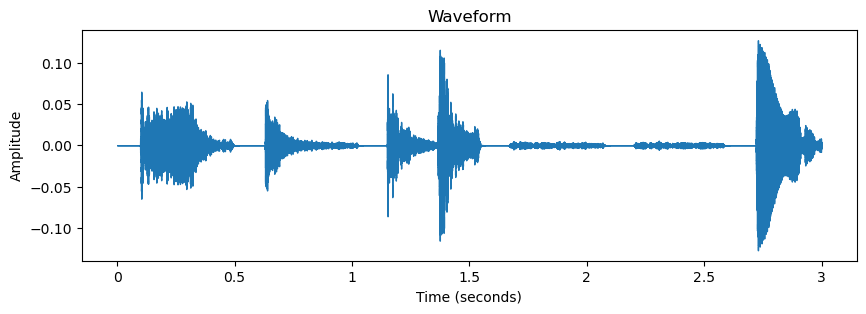

In [13]:
y, sr = librosa.load("cough.wav", sr=SR)

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.xlabel("Time (seconds)")

plt.ylabel("Amplitude")
plt.show()

## Frame the signal and compute short-time energy

The waveform itself is difficult to use directly for simple decision making.

So we divide the signal into short overlapping frames and compute the energy of each frame.

High-energy frames may correspond to coughs, speech, or other strong acoustic events.

In [14]:
FRAME_LENGTH = 512
HOP_LENGTH = 256

frames = librosa.util.frame(y, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)
energy = np.mean(frames**2, axis=0)

times = librosa.frames_to_time(
    np.arange(len(energy)),
    sr=sr,
    hop_length=HOP_LENGTH
)

print(f"Number of frames: {frames.shape[1]}")
print(f"Energy shape: {energy.shape}")
print(f"Energy min: {energy.min():.6f}")
print(f"Energy max: {energy.max():.6f}")

Number of frames: 186
Energy shape: (186,)
Energy min: 0.000000
Energy max: 0.005777


## Plot frame-level energy

Now we visualize the short-time energy over time.

This gives a much simpler representation than the raw waveform.

If cough events are stronger than the background, they may appear as peaks in the energy curve.１m

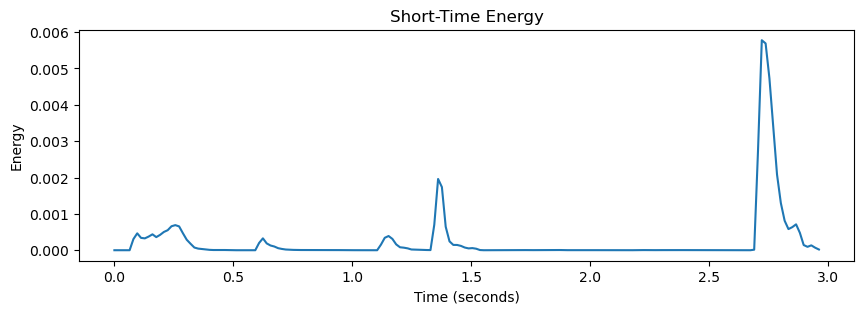

In [15]:
plt.figure(figsize=(10, 3))
plt.plot(times, energy)
plt.title("Short-Time Energy")
plt.xlabel("Time (seconds)")
plt.ylabel("Energy")
plt.show()

## Simple frame-level decision: cough / no-cough / uncertain

We now use a very simple rule based on short-time energy.

This is **not** a medical-grade model.  
It is only a teaching example.

We define two thresholds:

- if energy is high, classify the frame as `cough`
- if energy is low, classify the frame as `no-cough`
- if energy is in between, classify the frame as `uncertain`

This illustrates how uncertainty can be turned into a decision rule.

In [16]:
# Simple thresholds based on the observed energy range
low_threshold = np.percentile(energy, 75)
high_threshold = np.percentile(energy, 90)

frame_labels = []

for e in energy:
    if e >= high_threshold:
        frame_labels.append("cough")
    elif e <= low_threshold:
        frame_labels.append("no-cough")
    else:
        frame_labels.append("uncertain")

unique, counts = np.unique(frame_labels, return_counts=True)

print("Thresholds:")
print(f"  low_threshold  = {low_threshold:.6f}")
print(f"  high_threshold = {high_threshold:.6f}")

print("\nFrame-level counts:")
for u, c in zip(unique, counts):
    print(f"  {u}: {c}")

Thresholds:
  low_threshold  = 0.000115
  high_threshold = 0.000527

Frame-level counts:
  cough: 19
  no-cough: 139
  uncertain: 28


## Visualize frame-level decisions

We now visualize the energy curve together with the decision regions.

This helps us see which frames are treated as:

- cough
- no-cough
- uncertain

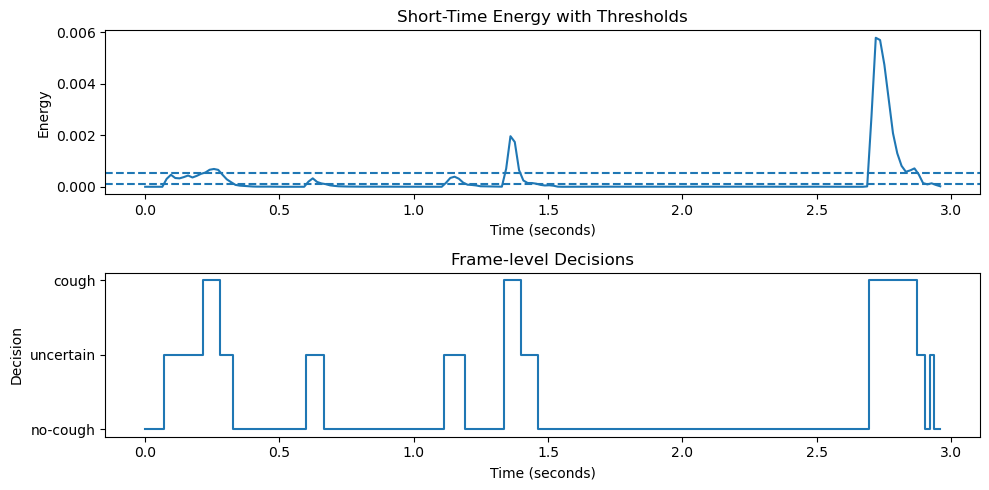

In [17]:
label_to_value = {
    "no-cough": 0,
    "uncertain": 1,
    "cough": 2
}

decision_values = np.array([label_to_value[label] for label in frame_labels])

plt.figure(figsize=(10, 5))

plt.subplot(2, 1, 1)
plt.plot(times, energy)
plt.axhline(low_threshold, linestyle="--")
plt.axhline(high_threshold, linestyle="--")
plt.title("Short-Time Energy with Thresholds")
plt.xlabel("Time (seconds)")
plt.ylabel("Energy")

plt.subplot(2, 1, 2)
plt.step(times, decision_values, where="mid")
plt.yticks([0, 1, 2], ["no-cough", "uncertain", "cough"])
plt.title("Frame-level Decisions")
plt.xlabel("Time (seconds)")
plt.ylabel("Decision")

plt.tight_layout()
plt.show()

## From frame-level to event-level detection

Now we convert frame-level decisions into cough events.

We group consecutive "cough" frames into a single event.

This corresponds to detecting cough segments in time.

In [18]:
events = []
current_event = None

for t, label in zip(times, frame_labels):
    # Build events from cough OR uncertain frames
    if label in ["cough", "uncertain"]:
        if current_event is None:
            current_event = [t, t]
        else:
            current_event[1] = t
    else:
        if current_event is not None:
            events.append(current_event)
            current_event = None

if current_event is not None:
    events.append(current_event)

print("Detected cough-related events:")
for i, (start, end) in enumerate(events, 1):
    print(f"Event {i}: {start:.2f}s – {end:.2f}s")

Detected cough-related events:
Event 1: 0.08s – 0.32s
Event 2: 0.61s – 0.66s
Event 3: 1.12s – 1.18s
Event 4: 1.34s – 1.46s
Event 5: 2.70s – 2.90s
Event 6: 2.93s – 2.93s


## Decision with uncertainty

So far, we converted frame-level cough decisions into cough events.

However, in a medical-audio setting, a system should not always make a hard decision.

If the evidence is weak or ambiguous, the system should output **uncertain**
and defer the case for further review.

Here, we use a simple rule:

- if an event contains many `cough` frames and few `uncertain` frames, accept it
- if an event contains many `uncertain` frames, refer it
- if no event is found, output `no-cough`

In [19]:
event_decisions = []

for start, end in events:
    mask = (times >= start) & (times <= end)
    labels_in_event = np.array(frame_labels)[mask]

    cough_count = np.sum(labels_in_event == "cough")
    uncertain_count = np.sum(labels_in_event == "uncertain")
    no_cough_count = np.sum(labels_in_event == "no-cough")

    total_relevant = cough_count + uncertain_count

    # More balanced teaching rule
    if total_relevant == 0:
        decision = "no-cough"
    else:
        uncertain_ratio = uncertain_count / total_relevant

        if cough_count == 0:
            decision = "refer"
        elif uncertain_ratio > 0.5:
            decision = "refer"
        else:
            decision = "accept as cough"

    event_decisions.append({
        "start": start,
        "end": end,
        "cough_frames": int(cough_count),
        "uncertain_frames": int(uncertain_count),
        "no_cough_frames": int(no_cough_count),
        "decision": decision
    })

print("Event-level decisions:")
for i, ev in enumerate(event_decisions, 1):
    print(
        f"Event {i}: {ev['start']:.2f}s–{ev['end']:.2f}s | "
        f"cough={ev['cough_frames']}, "
        f"uncertain={ev['uncertain_frames']}, "
        f"decision={ev['decision']}"
    )

if len(event_decisions) == 0:
    print("No cough-related event detected → final decision: no-cough")

Event-level decisions:
Event 1: 0.08s–0.32s | cough=4, uncertain=12, decision=refer
Event 2: 0.61s–0.66s | cough=0, uncertain=4, decision=refer
Event 3: 1.12s–1.18s | cough=0, uncertain=5, decision=refer
Event 4: 1.34s–1.46s | cough=4, uncertain=4, decision=accept as cough
Event 5: 2.70s–2.90s | cough=11, uncertain=2, decision=accept as cough
Event 6: 2.93s–2.93s | cough=0, uncertain=1, decision=refer


## Visualize event regions and decisions

We now overlay the detected event regions on the energy plot.

This makes it easier to connect:

- the raw signal,
- the energy feature,
- the detected event,
- and the final action.

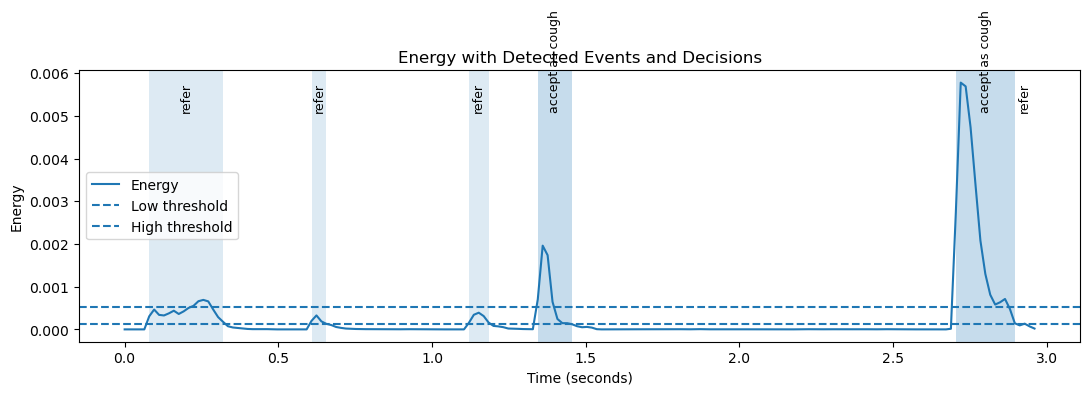

In [20]:
plt.figure(figsize=(11, 4))
plt.plot(times, energy, label="Energy")

plt.axhline(low_threshold, linestyle="--", label="Low threshold")
plt.axhline(high_threshold, linestyle="--", label="High threshold")

for ev in event_decisions:
    if ev["decision"] == "accept as cough":
        alpha = 0.25
    elif ev["decision"] == "refer":
        alpha = 0.15
    else:
        alpha = 0.10

    plt.axvspan(ev["start"], ev["end"], alpha=alpha)

    mid = 0.5 * (ev["start"] + ev["end"])
    ymax = max(energy) * 0.88
    plt.text(
        mid,
        ymax,
        ev["decision"],
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.title("Energy with Detected Events and Decisions")
plt.xlabel("Time (seconds)")
plt.ylabel("Energy")
plt.legend()
plt.tight_layout()
plt.show()


## Summary and Reflection

In this notebook, we implemented a simplified cough detection system.

Pipeline:

audio → waveform → energy → frame decision → event detection → final decision

Key observations:

- The raw waveform is complex and noisy.
- Energy provides a simple feature for detecting strong acoustic events.
- Frame-level predictions are not sufficient, so we need event-level reasoning.
- Uncertainty appears when the signal is not clearly cough or clearly no-cough.
- Decisions should depend not only on predictions, but also on uncertainty.

What we learned:

- A strong event can be accepted as cough.
- An ambiguous event should be referred rather than automatically accepted.
- This is a simple example of decision making under uncertainty.

Connection to the lecture:

- Week 7: signal → representation
- Week 8: prediction → uncertainty → decision

Key takeaway:

A real AI system is not just a predictor.  
It is a decision system that must handle uncertainty safely.